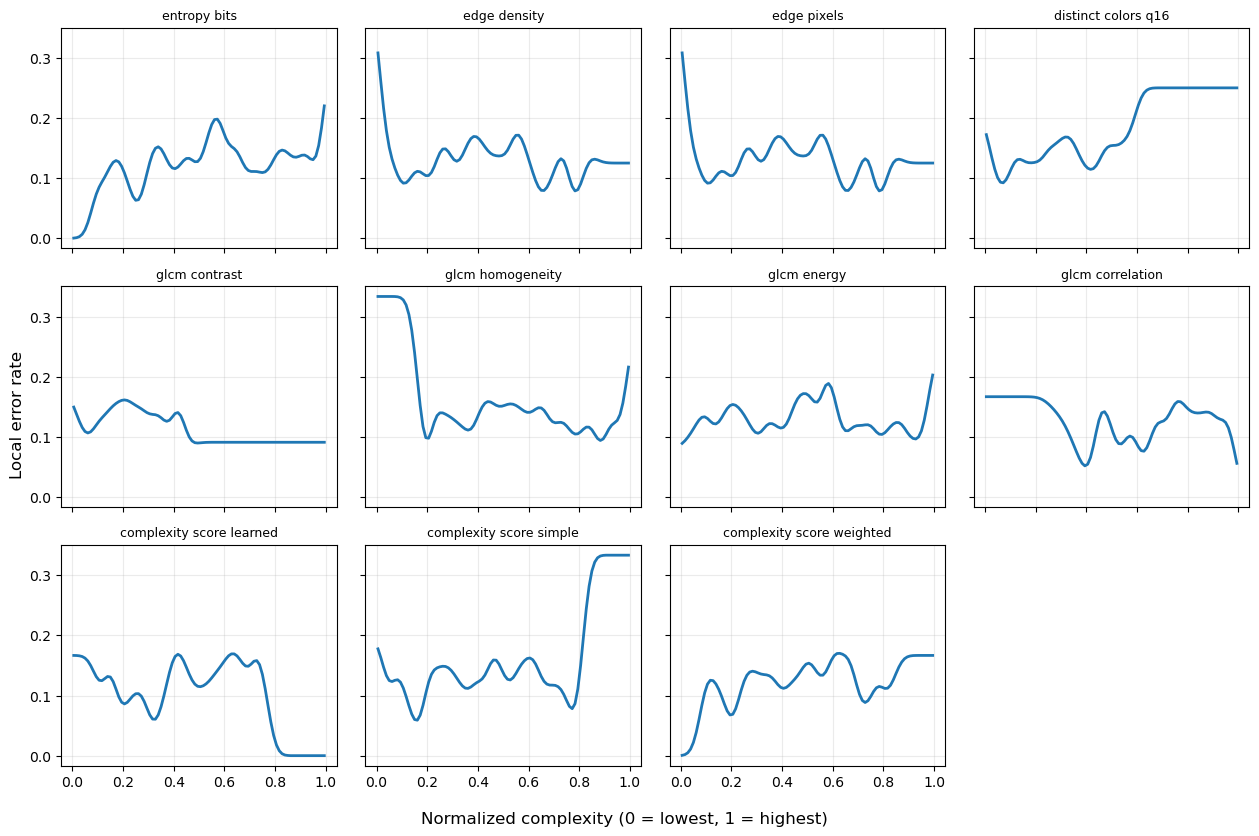

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load + merge (FULL IMAGE ONLY)
# ============================================================
cls  = pd.read_csv("csvs/onnx_imagenet_eval.csv")
cmp  = pd.read_csv("csvs/image_complexity_metrics.csv")

cls["key"] = cls["image_path"].astype(str).apply(lambda p: p.split("/")[-1])
cmp["key"] = cmp["path"].astype(str).apply(lambda p: p.split("/")[-1])

df = cls.merge(cmp, on="key", how="inner")
df["correct"] = df["correct"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)
df["error"] = 1 - df["correct"]

METRICS = [
    "entropy_bits",
    "edge_density",
    "edge_pixels",
    "distinct_colors_q16",
    "glcm_contrast",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation",
    "complexity_score_learned",
    "complexity_score_simple",
    "complexity_score_weighted",
]

# ============================================================
# Helper: gaussian smoother (pure numpy)
# ============================================================
def gaussian_smooth(y, sigma_bins=2.0):
    """
    Smooth a 1D array using a Gaussian kernel.
    sigma_bins is in "bins" units (since y is binned vs x).
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 5:
        return y

    radius = int(max(3, np.ceil(3 * sigma_bins)))
    kx = np.arange(-radius, radius + 1)
    k = np.exp(-(kx**2) / (2 * sigma_bins**2))
    k /= k.sum()

    # pad edges to avoid shrinking / edge drop
    ypad = np.pad(y, (radius, radius), mode="edge")
    ys = np.convolve(ypad, k, mode="valid")
    return ys

# ============================================================
# Helper: bin x then smooth y
# ============================================================
def smooth_error_curve_binned(df, metric, n_bins=80, min_count_per_bin=5, sigma_bins=2.0):
    d = df[["error", metric]].copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna()

    x = d[metric].to_numpy()
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y = d["error"].to_numpy()

    # bin edges and centers in [0,1]
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    bin_id = np.digitize(x, edges) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)

    y_mean = np.full(n_bins, np.nan, dtype=float)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        mask = (bin_id == b)
        counts[b] = int(mask.sum())
        if counts[b] >= min_count_per_bin:
            y_mean[b] = y[mask].mean()

    # interpolate across empty bins to keep a continuous curve
    good = np.isfinite(y_mean)
    if good.sum() < 3:
        return centers[good], y_mean[good]

    y_interp = np.interp(centers, centers[good], y_mean[good])
    y_smooth = gaussian_smooth(y_interp, sigma_bins=sigma_bins)

    return centers, y_smooth

# ============================================================
# Plot: ALL metrics as tiny multiples (grid of small plots)
# ============================================================
N_COLS = 4  # change this if you want more/less per row

metrics_present = [m for m in METRICS if m in df.columns]
n = len(metrics_present)
if n == 0:
    raise ValueError("None of the METRICS were found in df.columns. Check column names.")

n_rows = int(np.ceil(n / N_COLS))

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(3.2 * N_COLS, 2.8 * n_rows),
    sharex=True,
    sharey=True,
)

axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, metrics_present):
    xs, ys = smooth_error_curve_binned(
        df,
        m,
        n_bins=90,           # more bins -> more detail
        min_count_per_bin=6, # increase if noisy
        sigma_bins=2.5       # increase -> smoother
    )
    ax.plot(xs, ys, linewidth=2.0)
    ax.set_title(m.replace("_", " "), fontsize=9)
    ax.grid(alpha=0.25)

# delete unused axes (if grid has extra slots)
for j in range(len(metrics_present), len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel("Normalized complexity (0 = lowest, 1 = highest)", fontsize=12)
fig.supylabel("Local error rate", fontsize=12)
# fig.suptitle("How complexity metrics relate to error rate (all images)", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

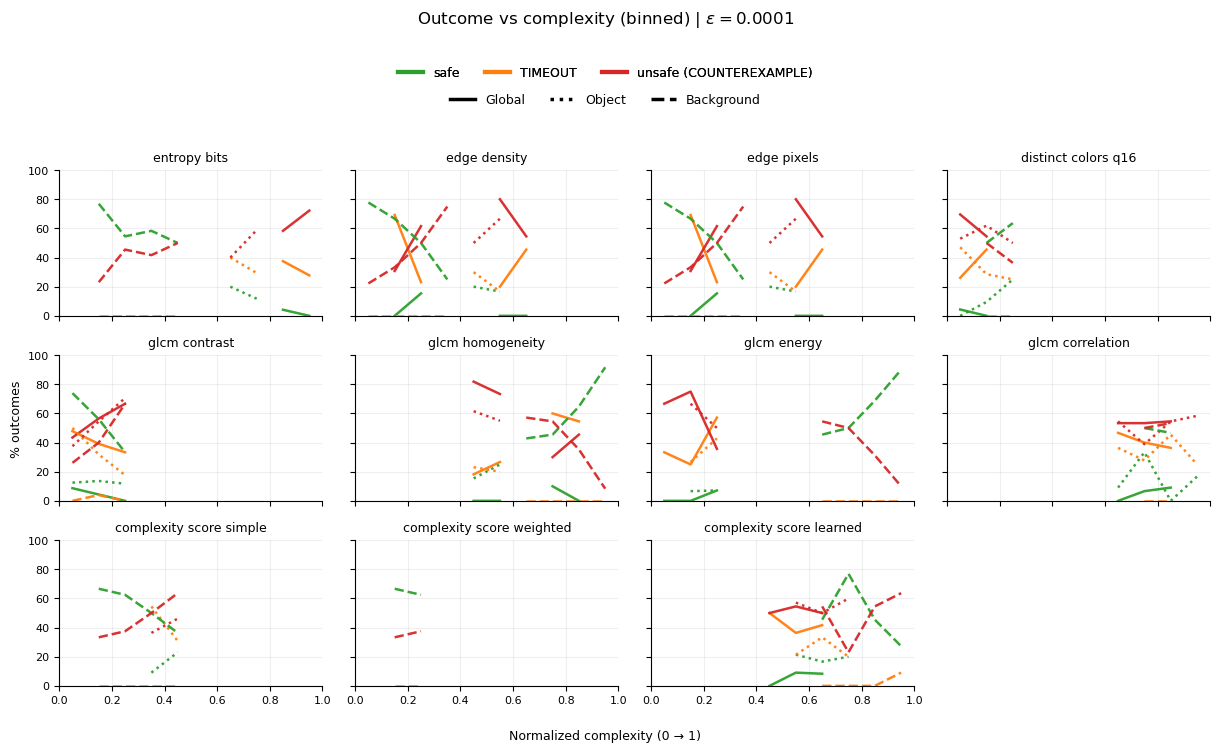

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
VERIF_CSV = "csvs/ALL_vggnet_triplets_merged.csv"

# semantic pairing: each variant uses its matching complexity source
SOURCES = [
    # (variant_name, csv_path, linestyle)
    ("Global",     "csvs/image_complexity_metrics.csv",     "-"),   # full-image
    ("Object",     "csvs/object_complexity_metrics.csv",    ":"),   # dotted
    ("Background", "csvs/background_complexity_metrics.csv","--"),  # dashed
]

METRICS = [
    "entropy_bits",
    "edge_density",
    "edge_pixels",
    "distinct_colors_q16",
    "glcm_contrast",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation",
    "complexity_score_simple",
    "complexity_score_weighted",
    "complexity_score_learned",
]

FIXED_K = 50176
KEEP_ONLY_SEG0_FOR_NONGLOBAL = True

# x-bins along normalized complexity
N_XBINS = 10
MIN_PER_BIN = 10

# outcomes (your combined_results strings)
RESULT_RENAME = {
    "unsat False": "safe",
    "sat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}
RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]
RESULT_COLORS = {
    "safe": "#2ca02c",
    "TIMEOUT": "#ff7f0e",
    "unsafe (COUNTEREXAMPLE)": "#d62728",
}

# If duplicates per (image, eps, variant), keep "worst"
WORST_FIRST = {
    "unsafe (COUNTEREXAMPLE)": 2,
    "TIMEOUT": 1,
    "safe": 0,
}

# plot sizing (smaller)
N_COLS = 4
PANEL_W = 3.1
PANEL_H = 2.2
LINE_W  = 1.8
TITLE_FS = 9
LABEL_FS = 9
TICK_FS = 8


# ============================================================
# HELPERS
# ============================================================
def stem_key(s: str) -> str:
    s = str(s).split("/")[-1].split("\\")[-1]
    return s.rsplit(".", 1)[0] if "." in s else s

def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])
    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask", "fix_non_mask"]):
        return "Object"
    return None

def outcome_reduce(series):
    s = series.dropna().astype(str)
    if len(s) == 0:
        return np.nan
    return max(s, key=lambda x: WORST_FIRST.get(x, -1))

def build_key_in_cmp(cmp: pd.DataFrame) -> pd.DataFrame:
    cmp = cmp.copy()
    if "key" in cmp.columns:
        cmp["key"] = cmp["key"].astype(str).apply(stem_key)
    elif "name" in cmp.columns:
        cmp["key"] = cmp["name"].astype(str).apply(stem_key)
    elif "path" in cmp.columns:
        cmp["key"] = cmp["path"].astype(str).apply(stem_key)
    else:
        raise ValueError("Complexity CSV must contain one of: key, name, path")
    return cmp

def normalize01(x):
    x = pd.to_numeric(x, errors="coerce")
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

def frac_per_bin(sub: pd.DataFrame, metric: str):
    """Return centers in [0,1] and dict outcome->%array (len N_XBINS)."""
    d = sub[[metric, "result_clean"]].dropna().copy()
    if len(d) == 0:
        centers = (np.linspace(0, 1, N_XBINS + 1)[:-1] + np.linspace(0, 1, N_XBINS + 1)[1:]) / 2
        return centers, {lab: np.full(N_XBINS, np.nan) for lab in RESULT_ORDER}, 0

    d["x"] = normalize01(d[metric])
    edges = np.linspace(0, 1, N_XBINS + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    d["bin"] = (np.digitize(d["x"], edges) - 1).clip(0, N_XBINS - 1)

    out = {lab: np.full(N_XBINS, np.nan, dtype=float) for lab in RESULT_ORDER}
    counts = np.zeros(N_XBINS, dtype=int)

    for b in range(N_XBINS):
        sb = d[d["bin"] == b]
        counts[b] = len(sb)
        if counts[b] >= MIN_PER_BIN:
            for lab in RESULT_ORDER:
                out[lab][b] = (sb["result_clean"] == lab).mean() * 100.0

    return centers, out, len(d)


# ============================================================
# LOAD VERIF
# ============================================================
ver = pd.read_csv(VERIF_CSV)

if "image" not in ver.columns:
    raise ValueError("combined_results.csv must contain an 'image' column.")

ver["image"] = ver["image"].astype(str).apply(stem_key)
ver["key"] = ver["image"]

ver["eps"] = pd.to_numeric(ver.get("eps", np.nan), errors="coerce")
ver["k"]   = pd.to_numeric(ver.get("k", np.nan), errors="coerce")
ver["result"] = ver.get("result", "").astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

ver["variant"] = ver.apply(classify_variant, axis=1)
ver = ver[ver["variant"].isin(["Global", "Object", "Background"])].copy()

if KEEP_ONLY_SEG0_FOR_NONGLOBAL and "segment_index" in ver.columns:
    ver = ver[(ver["variant"] == "Global") | (ver["segment_index"] == 0)].copy()

ver = ver[ver["result"].isin(RESULT_RENAME)].copy()
ver["result_clean"] = ver["result"].map(RESULT_RENAME)

ver = ver[ver["k"] == float(FIXED_K)].copy()
if len(ver) == 0:
    raise ValueError("No verification rows left after k filter.")

eps_values = sorted(ver["eps"].dropna().unique())
if len(eps_values) == 0:
    raise ValueError("No eps values found.")


# ============================================================
# PRELOAD COMPLEXITY TABLES
# ============================================================
cmp_tables = {}
for vname, path, _ls in SOURCES:
    cmp = pd.read_csv(path)
    cmp = build_key_in_cmp(cmp)
    cmp_tables[vname] = cmp


# ============================================================
# PLOT: for each eps, a grid of metrics
# ============================================================
for eps in eps_values:

    metrics_present = []
    for m in METRICS:
        # only keep metrics that exist in ALL three sources, otherwise it'll be half-empty
        ok = all(m in cmp_tables[vname].columns for vname, _, _ in SOURCES)
        if ok:
            metrics_present.append(m)

    if len(metrics_present) == 0:
        print(f"[SKIP eps={eps:g}] none of the metrics exist in all three complexity CSVs.")
        continue

    n = len(metrics_present)
    ncols = N_COLS
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(PANEL_W * ncols, PANEL_H * nrows),
        squeeze=False,
        sharex=True,
        sharey=True
    )
    axes = axes.reshape(-1)

    for ax_idx, metric in enumerate(metrics_present):
        ax = axes[ax_idx]
        ax.set_title(metric.replace("_", " "), fontsize=TITLE_FS)

        # plot 3 variants (linestyles), each with 3 outcomes (colors)
        for vname, _path, ls in SOURCES:
            cmp = cmp_tables[vname][["key", metric]].copy()
            cmp[metric] = pd.to_numeric(cmp[metric], errors="coerce")
            cmp = cmp.dropna(subset=[metric]).copy()

            dfx = ver[(ver["eps"] == eps) & (ver["variant"] == vname)].copy()
            dfx = dfx.merge(cmp, on="key", how="inner")

            # pair to one row per image for this eps+variant
            paired = (
                dfx.groupby(["image", "eps", "variant"])
                   .agg(complexity=(metric, "first"),
                        result_clean=("result_clean", outcome_reduce))
                   .reset_index()
            ).dropna(subset=["complexity", "result_clean"])

            if len(paired) == 0:
                continue

            centers, frac, n_used = frac_per_bin(
                paired.rename(columns={"complexity": metric}),
                metric
            )

            for lab in RESULT_ORDER:
                ax.plot(
                    centers, frac[lab],
                    linestyle=ls,
                    linewidth=LINE_W,
                    color=RESULT_COLORS[lab],
                    alpha=0.95
                )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 100)
        ax.grid(alpha=0.20)
        ax.tick_params(labelsize=TICK_FS)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # delete unused axes
    for j in range(len(metrics_present), len(axes)):
        fig.delaxes(axes[j])

    # --- Legends: one for colors (outcomes), one for linestyles (variants) ---
    outcome_handles = [
        plt.Line2D([0],[0], color=RESULT_COLORS[lab], lw=3, label=lab)
        for lab in RESULT_ORDER
    ]
    style_handles = [
        plt.Line2D([0],[0], color="black", lw=2.5, linestyle=ls, label=vname)
        for vname, _path, ls in SOURCES
    ]

    # place both legends at top
    leg1 = fig.legend(
        handles=outcome_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.05),
        fontsize=9
    )
    fig.add_artist(leg1)
    fig.legend(
        handles=style_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
        fontsize=9
    )

    fig.suptitle(rf"Outcome vs complexity (binned) | $\epsilon={eps:g}$", y=1.12, fontsize=12)
    fig.supxlabel("Normalized complexity (0 → 1)", fontsize=LABEL_FS)
    fig.supylabel("% outcomes", fontsize=LABEL_FS)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()